In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_from_disk, concatenate_datasets
from sklearn.metrics.pairwise import cosine_similarity
import datasets


/home/emilyx/miniconda3/envs/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define the base directory
base_dir = "/data/datasets/hf_cache/out/pythia-1b/fineweb/sample-350BT/random/step-00010000/grad/"

# Load the dataset
embedding_dataset = concatenate_datasets(
    [
        load_from_disk(f"{base_dir}{i}")
        for i in range(1)
    ]
).select(range(20000))

# Extract embeddings and scores
embeddings = np.array(embedding_dataset["__embedding"])

In [3]:
import os
metric_name = "oracle"
metric_split_path = os.path.join("/data/datasets/hf_cache/out/pythia-1b/fineweb/sample-350BT/random/step-00010000/", metric_name)
max_splits = len([name for name in os.listdir(metric_split_path) if os.path.isdir(os.path.join(metric_split_path, name))])
metrics_dataset = datasets.concatenate_datasets(
    [
        datasets.load_from_disk(
            os.path.join(metric_split_path, str(i))
        )
        for i in range(2)
    ]
)
print(metrics_dataset)
scores = np.array(metrics_dataset["scores"]).reshape(-1)

Dataset({
    features: ['input_ids', 'scores'],
    num_rows: 20000
})


In [6]:
# Calculate the average and standard deviation of scores
avg_score = np.mean(scores)
std_score = np.std(scores)

print(f"Average Score: {avg_score}")
print(f"Standard Deviation of Scores: {std_score}")

Average Score: 2.25199542671442
Standard Deviation of Scores: 0.019375494332737307


In [4]:
import numpy as np

# Compute pairwise cosine similarities
cosine_similarities = cosine_similarity(embeddings)

# Compute pairwise differences in scores
score_differences = np.abs(scores[:, np.newaxis] - scores[np.newaxis, :])

# Flatten the matrices for analysis
flattened_similarities = cosine_similarities.flatten()
flattened_score_differences = score_differences.flatten()

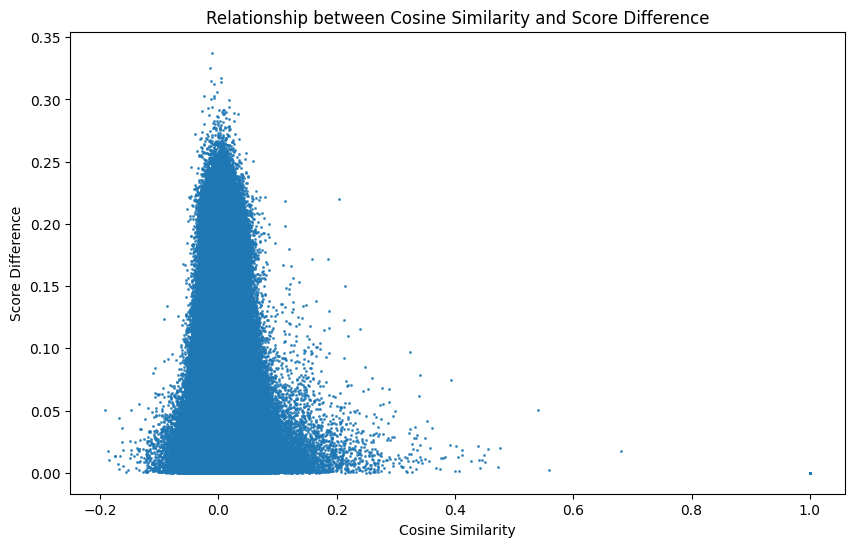

In [5]:
# Plot the relationship
plt.figure(figsize=(10, 6))
plt.scatter(flattened_similarities, flattened_score_differences, alpha=0.5, s=1)
plt.xlabel("Cosine Similarity")
plt.ylabel("Score Difference")
plt.title("Relationship between Cosine Similarity and Score Difference")
plt.show()

In [9]:
# Compute pairwise differences in scores
score_differences = np.abs(scores[:, np.newaxis] - scores[np.newaxis, :])

# Debug print to check the range of score differences
print(f"Min score difference: {np.min(score_differences)}")
print(f"Max score difference: {np.max(score_differences)}")
print(f"Average score difference: {np.mean(score_differences)}")
print(f"Standard deviation of score differences: {np.std(score_differences)}")


Min score difference: 0.0
Max score difference: 0.3375558853149414
Average score difference: 0.02093637684450984
Standard deviation of score differences: 0.0176773212309032


In [11]:
# Compute pairwise differences in scores
score_differences = np.abs(scores[:, np.newaxis] - scores[np.newaxis, :])

# Flatten the matrices for analysis
flattened_similarities = cosine_similarities.flatten()
flattened_score_differences = score_differences.flatten()

# Define the buckets
buckets = [(0, 0.2), (0.2, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.0)]

# Calculate and print metrics for each bucket
for bucket in buckets:
    mask = (flattened_similarities >= bucket[0]) & (flattened_similarities < bucket[1])
    bucket_score_differences = flattened_score_differences[mask]
    
    num_datapoints = len(bucket_score_differences)
    
    if num_datapoints > 0:
        min_diff = np.min(bucket_score_differences)
        max_diff = np.max(bucket_score_differences)
        avg_diff = np.mean(bucket_score_differences)
        std_diff = np.std(bucket_score_differences)
        
        print(f"Cosine Similarity Bucket {bucket[0]} - {bucket[1]}:")
        print(f"  Number of data points: {num_datapoints}")
        print(f"  Min score difference: {min_diff}")
        print(f"  Max score difference: {max_diff}")
        print(f"  Average score difference: {avg_diff}")
        print(f"  Standard deviation of score differences: {std_diff}")
    else:
        print(f"Cosine Similarity Bucket {bucket[0]} - {bucket[1]}: No data")

Cosine Similarity Bucket 0 - 0.2:
  Number of data points: 236940338
  Min score difference: 0.0
  Max score difference: 0.3172757625579834
  Average score difference: 0.020846278447241677
  Standard deviation of score differences: 0.017592517250128836
Cosine Similarity Bucket 0.2 - 0.4:
  Number of data points: 714
  Min score difference: 5.698204040527344e-05
  Max score difference: 0.2196798324584961
  Average score difference: 0.022069144315746317
  Standard deviation of score differences: 0.023617285432126576
Cosine Similarity Bucket 0.4 - 0.6:
  Number of data points: 36
  Min score difference: 0.0014147758483886719
  Max score difference: 0.050386905670166016
  Average score difference: 0.013600203726026747
  Standard deviation of score differences: 0.011160861333926672
Cosine Similarity Bucket 0.6 - 0.8:
  Number of data points: 2
  Min score difference: 0.017210721969604492
  Max score difference: 0.017210721969604492
  Average score difference: 0.017210721969604492
  Standard